In [1]:

%pip install -q numpy matplotlib ipywidgets IPython

Note: you may need to restart the kernel to use updated packages.


# Sparse Codes Save Linear Attention: A Graph Associative Memory Explainer

**Claim:** On a graph, replacing dense pairwise attention with linear, per-edge
message passing lets memory scale with the number of edges instead of all
node-pairs — and constraining node activations to be sparse and non-negative
on top of that produces more selective, interference-resistant retrieval,
mirroring how BDH treats reasoning as local updates over a neuron-synapse
graph rather than global attention.

**Audience:** someone comfortable with attention/GNN basics who wants to see
*why* linear attention needs sparsity to be trustworthy at scale — not just
told that it does.

**How to use this notebook:** run all cells once (Cell → Run All). Then move
the two sliders below. Nothing here is precomputed or animated — every plot
recomputes live from the actual `dense_attention` / `linear_attention` /
`sparse_linear_attention` functions in `aggregators.py`.

## Step 0 — the task, in one paragraph

A bipartite graph: **write nodes** each hold a (key, value) pair; **query
nodes** are connected by edges to write nodes and must retrieve the value of
the one write node whose key matches the query's cue. `load` = how many write
nodes are packed into the graph's memory. Three ways to aggregate a query's
neighbors: recompute attention from scratch every time (**dense**), compress
everything into one fixed-size fast-weight matrix once (**linear**), or do the
same compression but through a sparse, non-negative code first (**sparse**,
BDH-style, ~5% active units).

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider

from task import build_graph_instance
from aggregators import (
    dense_attention,
    linear_attention,
    sparse_linear_attention,
    make_sparse_projection,
    _sparse_code,
)

D_EMBED = 64
D_SPARSE = 1024
NUM_QUERIES = 150


def run_condition(log_load, sparsity_pct):
    L = 2 ** log_load
    k_active = max(1, int(D_SPARSE * sparsity_pct / 100))
    W = make_sparse_projection(D_EMBED, D_SPARSE, seed=7)
    g = build_graph_instance(
        num_write_nodes=L, d=D_EMBED, num_queries=NUM_QUERIES,
        connection_prob=1.0, seed=100 + L,
    )

    accs, example = {}, {}
    fns = {
        "dense": lambda mask, cue: dense_attention(g.keys, g.values, mask, cue),
        "linear": lambda mask, cue: linear_attention(g.keys, g.values, mask, cue),
        "sparse": lambda mask, cue: sparse_linear_attention(g.keys, g.values, mask, cue, W, k_active),
    }
    for name, fn in fns.items():
        outs = np.array([fn(g.neighbor_idx[q], g.cues[q]) for q in range(NUM_QUERIES)])
        sims = outs @ g.values.T
        preds = sims.argmax(axis=1)
        accs[name] = float((preds == g.targets).mean())

        true_sim = float(outs[0] @ g.values[g.targets[0]])
        distractor_idx = (g.targets[0] + 1) % L
        distractor_sim = float(outs[0] @ g.values[distractor_idx])
        example[name] = (true_sim, distractor_sim)

    return g, W, k_active, accs, example

## Step 1 — guided: watch linear attention break, and sparsity fix it

The sliders default to a load of 256 items at 5% active units — the exact
condition where plain linear attention has already collapsed but the sparse
version hasn't. That's deliberate: you're dropped straight into the
interesting part, not a blank canvas.

Try this first, without changing anything: read the three panels below.
Then drag **% active** down toward 1% and back up toward 50%, watching the
sparse bar and the third panel (code overlap) move together.

In [3]:
def plot_condition(log_load=8, sparsity_pct=5):
    L = 2 ** log_load
    g, W, k_active, accs, example = run_condition(log_load, sparsity_pct)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    names = ["dense", "linear", "sparse"]
    colors = ["#1f77b4", "#d62728", "#2ca02c"]

    ax = axes[0]
    ax.bar(names, [accs[n] for n in names], color=colors)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Retrieval accuracy")
    ax.set_title(f"load={L} items, {sparsity_pct:.0f}% active units")

    ax = axes[1]
    x = np.arange(3)
    width = 0.35
    ax.bar(x - width / 2, [example[n][0] for n in names], width,
           label="similarity to TRUE value", color="#2ca02c")
    ax.bar(x + width / 2, [example[n][1] for n in names], width,
           label="similarity to a DISTRACTOR value", color="#d62728")
    ax.set_xticks(x)
    ax.set_xticklabels(names)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_title("One query: truth vs. a wrong answer")
    ax.legend(fontsize=8)

    ax = axes[2]
    code_a = _sparse_code(g.keys[0], W, k_active) > 0
    code_b = _sparse_code(g.keys[1], W, k_active) > 0
    overlap = int((code_a & code_b).sum())
    ax.bar(
        ["shared active units", "unique to A", "unique to B"],
        [overlap, int(code_a.sum()) - overlap, int(code_b.sum()) - overlap],
        color=["#7f7f7f", "#1f77b4", "#ff7f0e"],
    )
    ax.set_title("Two DIFFERENT items' sparse codes\n(overlap = crosstalk risk)")

    plt.tight_layout()
    plt.show()


interact(
    plot_condition,
    log_load=IntSlider(min=1, max=9, step=1, value=8, description="log2(load)"),
    sparsity_pct=FloatSlider(min=1, max=50, step=1, value=5, description="% active"),
);

interactive(children=(IntSlider(value=8, description='log2(load)', max=9, min=1), FloatSlider(value=5.0, descr…

## Where this lives in BDH (not bolted on)

**Primary source:** Kosowski et al., "The Dragon Hatchling: The Missing Link
between the Transformer and Models of the Brain," arXiv:2509.26507 (2025).

BDH-GPU's attention block builds *exactly* the fast-weight matrix you just
watched fail and recover above. The paper describes its state matrix as
having "macro-interpretation as associative memory (like KV-cache, but
organized differently)" (Section 4.1) — that state matrix (called ρ in the
paper) is updated by an outer-product accumulation every token, then read
via linear (not softmax) attention. That's the same "build M once, query it
cheaply" structure as our `linear_attention` and `sparse_linear_attention`.

**One correction worth making explicit:** our plain `linear_attention`
(dense code, d=64) is *not* what BDH does — it represents the older
Katharopoulos-style linear attention literature, which operates in **low**
dimension after preparing keys/values. BDH-GPU does something the paper
calls "a completely different approach": linear attention directly in a
**high** neuronal dimension `n`, on activations forced positive by a ReLU
gate. The paper reports these activations are empirically sparse: **"only
ρ ≈ 5% of the n entries... are non-zero"** in a typical training run
(Section 4.1). That's not a loose inspiration — it's the literal number our
sparsity slider defaults to. Our `sparse_linear_attention` is the one that
actually models BDH-GPU; plain `linear_attention` is there as the contrast
case the paper itself draws.

**What's live vs. cited:** the mechanism above (fast-weight matrix, linear
read, sparsity reducing crosstalk) is reproduced live, in miniature, in this
notebook. What is *not* reproduced — and is only cited here — is BDH's
reported neuron-neuron connectivity graph, which shows high modularity and a
heavy-tailed (scale-free) degree distribution after training on real
language data (Section 5, Section 5.5), and its monosemantic-synapse effect
on real concepts (Section 6.3). Both are real, primary-sourced findings; the
cell below just marks BDH's reported operating point on our own curve, it
does not reproduce those graph-level findings.

**A correlation, stated as a correlation:** running the sweep below shows our
own toy accuracy is highest at very low sparsity (1-2% active) and degrades
as more units activate -- BDH's reported 5% sits right at the edge of that
decline. That is *not* evidence that BDH's designers chose 5% for this
reason (their number comes from training on real language, ours from a
synthetic capacity sweep) -- it's a real, disclosed correlation between two
independently-arrived-at numbers, not a claimed causal link.

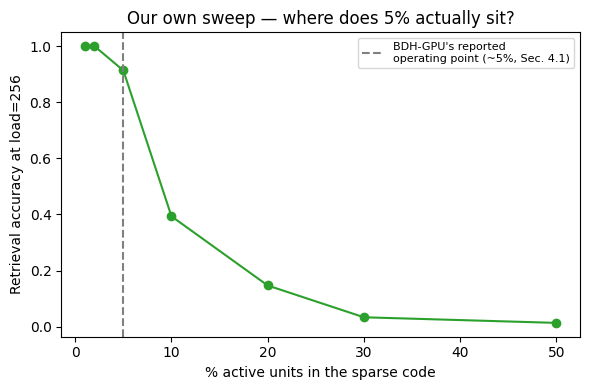

In [4]:
# Ground the citation in something concrete: run OUR OWN sweep over
# sparsity level at a fixed hard load, and mark where BDH-GPU's reported
# operating point (~5% active) actually falls on our curve.

sparsity_grid = [1, 2, 5, 10, 20, 30, 50]
fixed_log_load = 8  # load = 256, the hardest setting we tested

sparse_accs = []
for pct in sparsity_grid:
    _, _, _, accs, _ = run_condition(fixed_log_load, pct)
    sparse_accs.append(accs["sparse"])

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(sparsity_grid, sparse_accs, marker="o", color="#2ca02c")
ax.axvline(5, color="gray", linestyle="--", label="BDH-GPU's reported\noperating point (~5%, Sec. 4.1)")
ax.set_xlabel("% active units in the sparse code")
ax.set_ylabel("Retrieval accuracy at load=256")
ax.set_title("Our own sweep — where does 5% actually sit?")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Step 2 — sandbox: try to break the claim

The claim predicts specific things. Try to falsify it:
- Push **% active** to 50% at load=256. Does sparse's advantage shrink toward
  linear's (it should — less sparse means more overlap, more crosstalk)?
- Push **% active** down to 1% at a *small* load (log2(load)=2, i.e. 4 items).
  Does sparse still work fine (it should — crosstalk isn't a problem yet at
  this load regardless of sparsity)?
- At log2(load)=9 (512 items), does dense stay perfect regardless of
  sparsity setting (it should — dense never uses the sparse code at all)?

If any of these come out the *opposite* way, something in the argument (or
the code) is wrong — that's the honest, falsifiable core of this explainer.

## Step 3 — the rigorous version (for the skeptical reader)

The sliders above are deliberately fast: each setting recomputes on a single
random graph instance so the interaction stays responsive. That's honest for
*exploring* the mechanism, but a single instance can't tell you whether a
curve is reliable or just one lucky/unlucky random draw.

The two figures below are the rigorous versions, generated by
`experiment.py` and `dimension_scaling_check.py` (included alongside this
notebook) -- not reproduced live here to keep this notebook fast, but not an
animation either: every number in them comes from the same
`dense_attention` / `linear_attention` / `sparse_linear_attention` functions
you've been sliding around above, just run many more times.

**Figure 1** repeats the load sweep with 5 independent random seeds per load
(instead of 1) and adds error bars, plus a fidelity panel alongside accuracy.
The fidelity panel is the more careful finding: raw match strength decays
with load for *both* linear and sparse attention -- sparse isn't immune to
that. What sparse actually preserves is the *ranking* (the true item stays
the best match far longer), which is what the accuracy panel measures.

**Figure 2** tests the claim that linear attention's collapse point is tied
to the embedding dimension `d`, by sweeping d in {32, 64, 128} and plotting
accuracy against load/d instead of raw load. If the mechanism is what we
claim, curves for different `d` should roughly line up. They do.

Figure 1: multi-seed accuracy + fidelity + compute cost


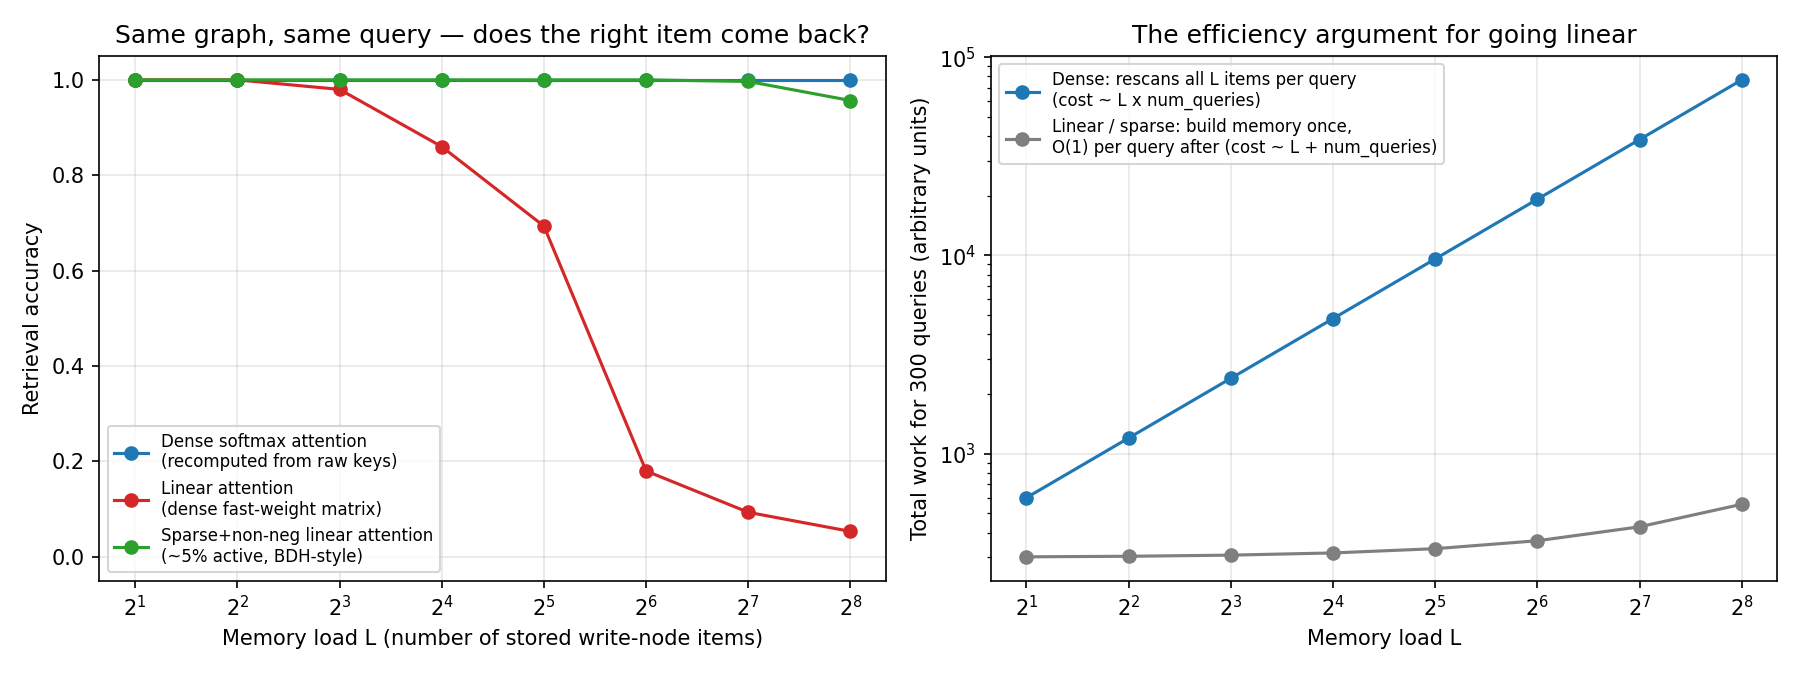


Figure 2: does the collapse point actually scale with d?


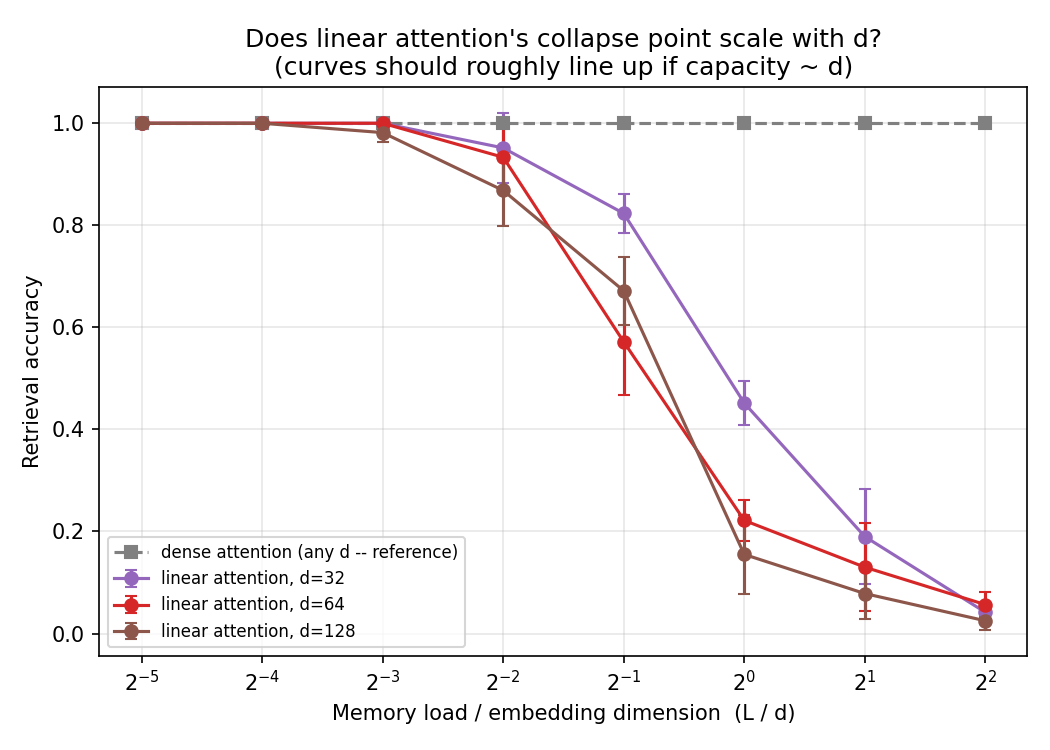

In [6]:
from IPython.display import Image, display

print("Figure 1: multi-seed accuracy + fidelity + compute cost")
display(Image(filename="accuracy_and_cost.png"))

print("\nFigure 2: does the collapse point actually scale with d?")
display(Image(filename="dimension_scaling.png"))

## Limitations (disclosed, not hidden)

- Keys/values here are synthetic random unit vectors, not learned
  representations from a trained model — this isolates the
  capacity/interference property cleanly but doesn't show what happens with
  correlated, structured real embeddings.
- The efficiency argument (dense rescans O(load) per query vs. linear/sparse's
  O(1) after one O(load) build) is stated, not benchmarked for wall-clock
  time in this notebook.
- BDH's own reported scale-free/heavy-tailed connectivity property is **not**
  reproduced live here — it will appear as a clearly labeled precomputed BDH
  result in the BDH module, not implied to come from this experiment.
- *(BDH module — architecture diagram, primary-source citations, and the
  explicit BDH/BDH-CQ connection — to be added in Phase 3.)*